In [1]:
import numpy as np 

## maxwell 

maxwell times of earth materials

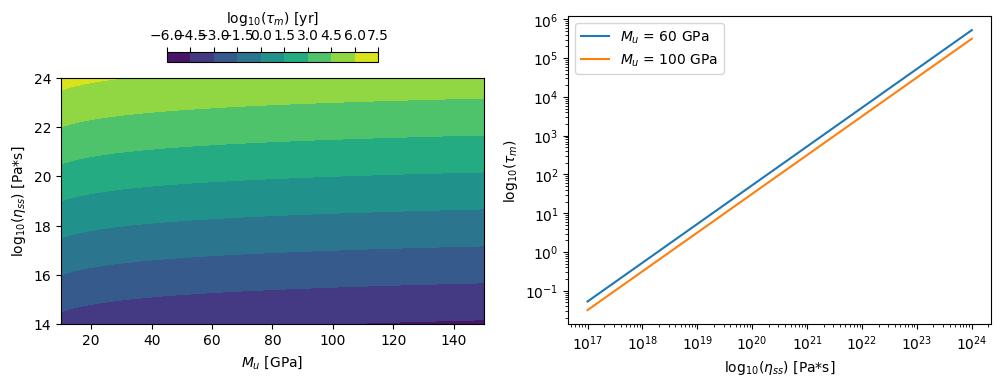

In [2]:
import numpy as np 
from  unyt import unyt_array, unyt_quantity
import matplotlib.pyplot as plt 


def maxwell_time(Mu, eta):
    return eta / Mu 

# calculate maxwell times over a large range of unrelaxed moduli 
# and viscosity values 
Mu = unyt_array(np.linspace(10, 150, 100), 'GPa') 
eta = unyt_array(np.logspace(14, 24, 90), 'Pa * s')
Mu_g, eta_g = np.meshgrid(Mu, eta) 
tau_m = (maxwell_time(Mu_g, eta_g)).to('year')

fig, axs = plt.subplots(ncols=2, nrows = 1, figsize=(12,4))

c = axs[0].contourf(Mu, np.log10(eta) , np.log10(tau_m))
axs[0].set_xlabel(f"$M_u$ [{Mu.units}]")
axs[0].set_ylabel(r'log$_{10}(\eta_{ss})$' + f" [{eta.units}]")
plt.colorbar(c, ax=axs[0],
             label=r'log$_{10}(\tau_m)$' + f" [{tau_m.units}]", 
             shrink=0.5,
             location='top')


eta = unyt_array(np.logspace(17, 24, 100), 'Pa * s')
for Mu in unyt_array([60, 100], 'GPa'):
    tau_m = (maxwell_time(Mu, eta)).to('year')
    axs[1].loglog(eta, tau_m, label=f"$M_u$ = {Mu}")
axs[1].set_ylabel(r'log$_{10}(\tau_m)$')
axs[1].set_xlabel(r'log$_{10}(\eta_{ss})$' + f" [{eta.units}]")
axs[1].legend()



Text(0.5, 1.0, 'Maxwell Solid')

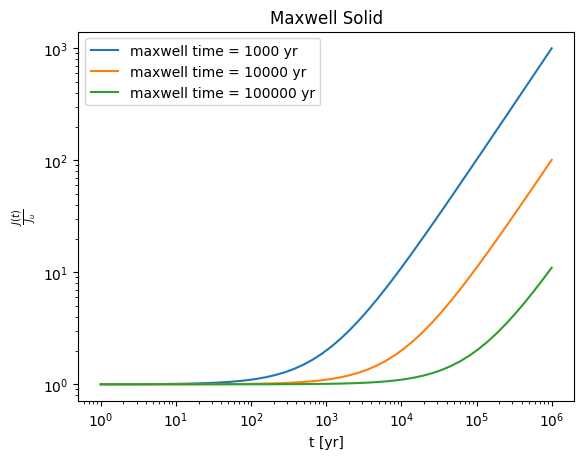

In [3]:
import numpy as np 
import unyt 
import matplotlib.pyplot as plt 

def J_Ju_maxwell(t, tau_m):
    return 1 + t / tau_m
    
tau_m_values = unyt.unyt_array([1e3, 1e4, 1e5], 'year')
t = unyt.unyt_array(np.logspace(0, 6), 'year')

f, axs = plt.subplots(1)
for tau_m in tau_m_values:
    J_t = J_Ju_maxwell(t, tau_m)
    axs.plot(t, J_t, label = f"maxwell time = {tau_m.astype(int)}")
axs.set_xscale('log')
axs.set_yscale('log')
axs.legend()
axs.set_xlabel(f"t [{t.units}]")
axs.set_ylabel(r"$\frac{J(t)}{J_u}$")
axs.set_title("Maxwell Solid")


In [4]:
unyt.year

yr

andrade 

https://essopenarchive.org/doi/full/10.22541/essoar.169008299.99203183 nice easy description

5.999999999767169 dimensionless


Text(0.5, 1.0, 'Maxwell-Normalized Andrade Solid')

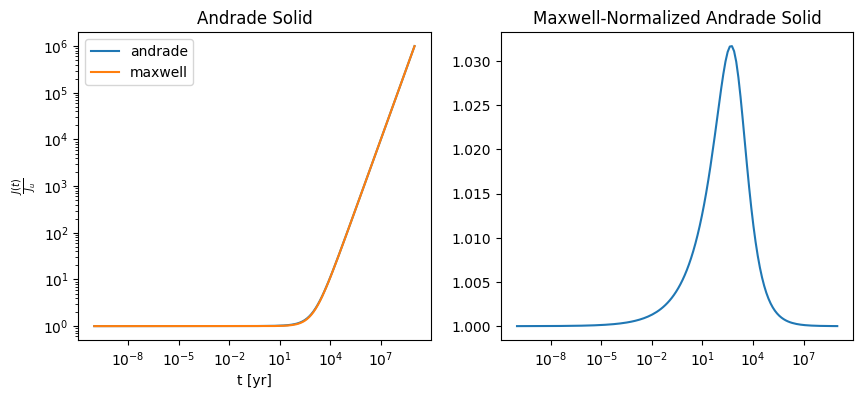

In [9]:
import numpy as np 
import unyt 
import matplotlib.pyplot as plt 

def J_Ju_andrade(t, beta, Ju, alpha, tau_m):
    J_t = Ju + beta * t**alpha + Ju * t / tau_m
    return J_t / Ju

alpha = 1.0 / 3.0
beta = 1e-4 * 1./(unyt.year**alpha)  * 1/unyt.GPa
Mu = unyt_quantity(60, 'GPa')
Ju = 1 / Mu
tau_m_values = unyt.unyt_array([1e3], 'year')
t = unyt.unyt_array(np.logspace(-10, 9, 150), 'year')

f, axs = plt.subplots(ncols=2,nrows=1,figsize=(10,4))
for tau_m in tau_m_values:    
    J_t = J_Ju_andrade(t, beta, Ju, alpha, tau_m)
    axs[0].plot(t, J_t, label = f"andrade")
    J_tmax = J_Ju_maxwell(t, tau_m)
    print(np.max(J_t - J_tmax))
    axs[0].plot(t, J_tmax, label = f"maxwell")
    axs[1].plot(t, J_t / J_tmax)
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].set_xlabel(f"t [{t.units}]")
axs[0].set_ylabel(r"$\frac{J(t)}{J_u}$")
axs[0].set_title("Andrade Solid")
axs[1].set_title("Maxwell-Normalized Andrade Solid")

## burgers 


In [ ]:
def J_Ju_andrade(t, beta, Ju, alpha, tau_m):
    J_t = Ju + beta * t**alpha + Ju * t / tau_m
    return J_t / Ju

## frequency domain